# VAE Pipeline Notebook
Step-by-step cells for data loading, model training, clustering, and interpolation.

In [1]:

# %matplotlib inline
# ===================== SETUP / IMPORTS =====================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from pathlib import Path
from tifffile import imread
from tqdm import tqdm
import numpy as np
import pandas as pd
import random
import json

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

import hdbscan
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Reproducibility
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    # Optional strict determinism
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

# ===================== CONFIG =====================
is_3d = False          # Set True for 3D .tif data
image_size = 64        # For 3D, assumes D=H=W=image_size after resize
latent_dim = 64
batch_size = 8
epochs = 1
lr = 1e-3

data_path_2D = "/mnt/y/vaibhav/SITE/17jul25/imagedata_mammaSITE_2D"
data_path_3D = "/mnt/y/vaibhav/SITE/17jul25/imagedata_mammaSITE_3D"
data_path = data_path_3D if is_3d else data_path_2D
stats_path = "norm_stats.json"


## Dataset

In [2]:
class TifDataset(Dataset):
    """
    Loads 2D (H,W) or multichannel 2D (C,H,W) or 3D (D,H,W) / (C,D,H,W) .tif files.
    - If normalize=True:
        * use per-channel (img - mean) / std when mean/std provided
        * otherwise scale to [-1, 1] via (x - 0.5) / 0.5
    - Always resizes to image_size (2D bilinear / 3D trilinear).
    """
    def __init__(self, root_dir, image_size=64, is_3d=False,
                 num_channels=None, mean_vals=None, std_vals=None,
                 normalize=True, debug=False):
        self.paths = sorted(list(Path(root_dir).rglob("*.tif")))
        if len(self.paths) == 0:
            raise FileNotFoundError(f"No .tif files found under {root_dir}")
        self.image_size = image_size
        self.is_3d = is_3d
        self.num_channels = num_channels
        self.mean_vals = mean_vals
        self.std_vals = std_vals
        self.normalize = normalize
        self.debug = debug

    def __len__(self):
        return len(self.paths)

    def _to_tensor_ch_first(self, img):
        # 2D
        if not self.is_3d:
            if img.ndim == 2:
                img = np.expand_dims(img, 0)              # (H,W)->(1,H,W)
            elif img.ndim == 3:
                if img.shape[0] != min(img.shape):
                    img = np.transpose(img, (2,0,1))       # (H,W,C)->(C,H,W)
            else:
                raise ValueError(f"[2D] Unsupported shape: {img.shape}")
        # 3D
        else:
            if img.ndim == 3:
                img = np.expand_dims(img, 0)              # (D,H,W)->(1,D,H,W)
            elif img.ndim == 4:
                if img.shape[0] != min(img.shape):
                    img = np.transpose(img, (3,0,1,2))     # (D,H,W,C)->(C,D,H,W)
            else:
                raise ValueError(f"[3D] Unsupported shape: {img.shape}")
        return img

    def _resize_tensor(self, x):
        # x: torch tensor (C,H,W) or (C,D,H,W)
        if not self.is_3d:
            if x.shape[-2:] != (self.image_size, self.image_size):
                x = F.interpolate(x.unsqueeze(0), size=(self.image_size, self.image_size),
                                  mode="bilinear", align_corners=False).squeeze(0)
        else:
            if x.shape[-3:] != (self.image_size, self.image_size, self.image_size):
                x = F.interpolate(x.unsqueeze(0), size=(self.image_size, self.image_size, self.image_size),
                                  mode="trilinear", align_corners=False).squeeze(0)
        return x

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = imread(p)  # numpy
        original_shape = img.shape

        # --- channel-first as numpy ---
        img = self._to_tensor_ch_first(img)

        # --- dtype-aware scaling to [0,1] BEFORE torch tensor ---
        if img.dtype == np.uint8:
            img = img.astype(np.float32) / 255.0
        elif img.dtype == np.uint16:
            img = img.astype(np.float32) / 65535.0
        else:
            # If already float or unusual dtype, clip to [0,1] for safety
            img = np.clip(img.astype(np.float32), 0.0, 1.0)

        # --- now convert to torch ---
        img = torch.from_numpy(img)

        # --- resize in raw space ---
        img = self._resize_tensor(img)

        # --- normalize if requested ---
        if self.normalize:
            if self.mean_vals is not None and self.std_vals is not None:
                view_shape = (-1,) + (1,) * (img.ndim - 1)
                mean = torch.tensor(self.mean_vals, dtype=torch.float32).view(view_shape)
                std  = torch.tensor(self.std_vals,  dtype=torch.float32).view(view_shape)
                img = (img - mean) / (std + 1e-6)   # a bit larger eps for zero-std safety
            else:
                img = (img - 0.5) / 0.5  # [-1,1] fallback

        if self.debug:
            print(f"{p.name} original: {original_shape} -> final: {tuple(img.shape)} "
                  f"| range [{img.min().item():.3f}, {img.max().item():.3f}]")

        return img, 0

## Normalization Stats (computed on RAW images)

In [3]:
# ===== Exact full-dataset channel stats with a detailed progress bar =====
import time
from tqdm.auto import tqdm

def compute_dataset_channel_stats_full(
    dataset,
    num_channels,
    batch_size=16,
    num_workers=4,
    use_gpu_for_stats=False
):
    """
    Exact per-channel mean/std over the entire dataset (normalize=False).
    Uses numerically-stable Welford aggregation in a single pass.
    Shows a detailed progress bar with ETA.
    """
    total_items = len(dataset)

    # DataLoader streams batches from disk; tune workers/batch_size for your machine
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=use_gpu_for_stats,
        drop_last=False,
        persistent_workers=(num_workers > 0),
        prefetch_factor=2 if num_workers > 0 else None,
    )

    # Welford accumulators on CPU in float64 for stability
    mean = torch.zeros(num_channels, dtype=torch.float64)
    M2   = torch.zeros(num_channels, dtype=torch.float64)  # sum of squared deviations
    n    = torch.zeros(num_channels, dtype=torch.float64)  # sample count per channel

    # If you set use_gpu_for_stats=True and CUDA is available, reduce on GPU
    dev = torch.device("cuda" if (use_gpu_for_stats and torch.cuda.is_available()) else "cpu")

    # Progress bar shows number of images processed
    pbar = tqdm(
        total=total_items,
        desc="Computing full-channel stats",
        unit="img",
        dynamic_ncols=True,
        leave=True
    )

    with torch.no_grad():
        for x, _ in loader:
            B = x.shape[0]                # batch size actually loaded
            pbar.update(B)                # move progress bar forward by B

            # Flatten spatial dims so each channel becomes (B * pixels) long
            # x: (B, C, ...) -> (B, C, P)
            x = x.view(B, num_channels, -1)

            if dev.type == "cuda":
                # Move to GPU for fast per-batch reductions (optional)
                x = x.to(dev, non_blocking=True).to(torch.float64)
                s1 = x.sum(dim=(0, 2)).to("cpu")               # per-channel sum
                s2 = (x * x).sum(dim=(0, 2)).to("cpu")         # per-channel sum of squares
            else:
                # Stay on CPU; use float64 for numerical safety
                x = x.to(torch.float64)
                s1 = x.sum(dim=(0, 2))
                s2 = (x * x).sum(dim=(0, 2))

            # k = number of samples contributing to this batch per channel
            k = torch.full((num_channels,), x.shape[0] * x.shape[2], dtype=torch.float64)

            # Convert batch sums to batch mean/M2, then merge with global Welford state
            mean_b = s1 / k.clamp_min(1)                       # batch mean per channel
            M2_b   = s2 - k * (mean_b * mean_b)                # batch M2 per channel

            n_old  = n.clone()
            n      = n + k
            delta  = mean_b - mean                             # difference between means
            mean   = mean + delta * (k / n.clamp_min(1))       # merged mean
            M2     = M2 + M2_b + (delta * delta) * (n_old * k / n.clamp_min(1))  # merged M2

    pbar.close()

    # Final variance and std; clamp tiny negatives from FP error
    var = (M2 / n.clamp_min(1)).clamp_min(0)
    std = torch.sqrt(var)

    return mean.to(torch.float32).tolist(), std.to(torch.float32).tolist()

# ===== Use the function (loads cache if present; else computes/saves) =====
start = time.time()

if Path(stats_path).exists():
    with open(stats_path, "r") as f:
        stats = json.load(f)
    mean_vals = stats["mean"]
    std_vals = stats["std"]
    num_channels = stats["num_channels"]
    print("📂 Loaded cached mean/std from file!")
else:
    # RAW dataset to avoid biasing stats (normalize=False)
    temp_ds = TifDataset(
        data_path,
        image_size=image_size,
        is_3d=is_3d,
        mean_vals=None,
        std_vals=None,
        normalize=False,
        debug=False
    )
    # Detect channel count from a sample
    sample_img, _ = temp_ds[0]
    num_channels = sample_img.shape[0]

    # Run exact pass over the entire dataset
    mean_vals, std_vals = compute_dataset_channel_stats_full(
        temp_ds,
        num_channels=num_channels,
        batch_size=16,       # ↑ if RAM is comfy, ↓ if memory tight
        num_workers=6,       # try 4–8 depending on your CPU/disk
        use_gpu_for_stats=False  # set True if GPU is idle & I/O isn’t the bottleneck
    )

    with open(stats_path, "w") as f:
        json.dump({"mean": mean_vals, "std": std_vals, "num_channels": num_channels}, f)
    print(f"✅ Computed and saved mean/std to {stats_path}")

print(f"⏳ Elapsed: {(time.time() - start)/60:.2f} min")
print("mean_vals:", mean_vals)
print("std_vals:", std_vals)




Computing full-channel stats:   0%|                                                    | 0/10656 [00:00<?, ?im…

✅ Computed and saved mean/std to norm_stats.json
⏳ Elapsed: 12.42 min
mean_vals: [0.0010025884257629514, 0.00894865207374096, 0.00272792368195951, 0.035254258662462234, 0.006404591724276543]
std_vals: [0.0026090785395354033, 0.005467358976602554, 0.003919412847608328, 0.02979285828769207, 0.0008214259287342429]


## Final Dataset & Loader

In [4]:

dataset = TifDataset(
    root_dir=data_path,
    image_size=image_size,
    is_3d=is_3d,
    num_channels=num_channels,
    mean_vals=mean_vals,
    std_vals=std_vals,
    normalize=True,
    debug=False
)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

img, _ = dataset[0]
channels = img.shape[0]
print(f"One image shape: {tuple(img.shape)} | Detected channels: {channels}")


One image shape: (5, 64, 64) | Detected channels: 5


## Models: VAE2D & VAE3D

In [14]:
class VAE2D(nn.Module):
    """
    Dynamic 2D VAE:
    - Detects image resolution at first forward()
    - Builds encoder/decoder dynamically
    - Uses /8 downsampling (3 stride-2 layers)
    """
    def __init__(self, in_channels, latent_dim):
        super().__init__()
        self.in_channels = in_channels
        self.latent_dim = latent_dim
        self.built = False

    def build(self, x):
        B, C, H, W = x.shape
        assert H == W, "VAE2D requires square images."
        self.image_size = H

        h8 = H // 8
        if h8 < 1:
            raise ValueError(f"Image too small for /8 downsampling: {H}")

        # ===== Encoder =====
        self.encoder = nn.Sequential(
            nn.Conv2d(self.in_channels, 32, 4, 2, 1),  # /2
            nn.ReLU(True),
            nn.Conv2d(32, 64, 4, 2, 1),                # /4
            nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1),               # /8
            nn.ReLU(True),
            nn.Flatten()
        )

        hidden_dim = 128 * h8 * h8
        self.hidden_dim = hidden_dim

        # Latent projections
        self.fc_mu     = nn.Linear(hidden_dim, self.latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, self.latent_dim)

        # ===== Decoder =====
        self.decoder_input = nn.Linear(self.latent_dim, hidden_dim)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, h8, h8)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # /4
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # /2
            nn.ReLU(True),
            nn.ConvTranspose2d(32, self.in_channels, 4, 2, 1),  # original size
            nn.Tanh()
        )

        self.apply(self._init)
        self.to(x.device)      # <<< ensures CPU/GPU consistency
        self.built = True

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)

    def forward(self, x, return_z=False, latent_type="sampled"):
        if not self.built:
            self.build(x)

        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z = mu if latent_type == "mu" else self.reparameterize(mu, logvar)
        x_hat = self.decoder(self.decoder_input(z))

        if return_z:
            return x_hat, mu, logvar, z
        return x_hat, mu, logvar



# =======================================================================
#                              VAE3D (dynamic)
# =======================================================================

class VAE3D(nn.Module):
    """
    Dynamic 3D VAE:
    - Detects (D,H,W) at first forward()
    - Builds encoder/decoder dynamically
    - Uses deeper /4 design
    """
    def __init__(self, in_channels, latent_dim):
        super().__init__()
        self.in_channels = in_channels
        self.latent_dim = latent_dim
        self.built = False

    def build(self, x):
        B, C, D, H, W = x.shape
        assert D == H == W, "VAE3D requires cubic volumes."
        self.image_size = H

        d4 = D // 4
        if d4 < 1:
            raise ValueError(f"Volume too small for /4 downsampling: {D}")

        # ===== Encoder =====
        self.encoder = nn.Sequential(
            nn.Conv3d(self.in_channels, 32, 4, 2, 1),  # /2
            nn.ReLU(True),
            nn.Conv3d(32, 32, 3, 1, 1),
            nn.ReLU(True),
            nn.Conv3d(32, 64, 4, 2, 1),                # /4
            nn.ReLU(True),
            nn.Conv3d(64, 64, 3, 1, 1),
            nn.ReLU(True),
            nn.Flatten()
        )

        hidden_dim = 64 * d4 * d4 * d4
        self.hidden_dim = hidden_dim

        # Latent projections
        self.fc_mu     = nn.Linear(hidden_dim, self.latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, self.latent_dim)

        # ===== Decoder =====
        self.decoder_input = nn.Linear(self.latent_dim, hidden_dim)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, d4, d4, d4)),
            nn.ConvTranspose3d(64, 64, 3, 1, 1),
            nn.ReLU(True),
            nn.ConvTranspose3d(64, 32, 4, 2, 1),  # /2
            nn.ReLU(True),
            nn.ConvTranspose3d(32, 32, 3, 1, 1),
            nn.ReLU(True),
            nn.ConvTranspose3d(32, self.in_channels, 4, 2, 1),  # original size
            nn.Tanh()
        )

        self.apply(self._init)
        self.to(x.device)       # <<< HERE is the device safety
        self.built = True

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Conv3d, nn.ConvTranspose3d, nn.Linear)):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)

    def forward(self, x, return_z=False, latent_type="sampled"):
        if not self.built:
            self.build(x)

        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z = mu if latent_type == "mu" else self.reparameterize(mu, logvar)
        x_hat = self.decoder(self.decoder_input(z))

        if return_z:
            return x_hat, mu, logvar, z
        return x_hat, mu, logvar



## Wrapper: VAEUnified

In [15]:
class VAEUnified(nn.Module):
    """
    Wrapper for dynamic VAE2D / VAE3D.
    """
    def __init__(self, in_channels, latent_dim, is_3d=False):
        super().__init__()
        self.is_3d = is_3d
        self.model = VAE3D(in_channels, latent_dim) if is_3d else VAE2D(in_channels, latent_dim)

    def forward(self, x, return_z=False, latent_type="sampled"):
        return self.model(x, return_z=return_z, latent_type=latent_type)


## Training

In [16]:
# ===================== DEVICE & MODEL =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAEUnified(
    in_channels=channels,
    latent_dim=latent_dim,
    is_3d=is_3d,   # dynamic build on first forward
).to(device)

# 🔧 Warm-start build: run a tiny forward pass to initialize layers
x0, _ = next(iter(loader))          # grab one batch
x0 = x0.to(device)
with torch.no_grad():
    _ = model(x0[:1], return_z=False, latent_type="sampled")  # triggers build

# (optional) sanity print: how many trainable params now?
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model built. Trainable params: {n_params:,}")

# ===================== OPTIMIZER & TRAINING =====================
optimizer = optim.Adam(model.parameters(), lr=lr)

# Optional: mixed precision
use_amp = (device.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

warmup_epochs = max(1, int(0.3 * epochs))
beta_max = 1.0

for epoch in range(epochs):
    model.train()
    total_loss = total_recon = total_kl = 0.0
    beta = beta_max * min(1.0, (epoch + 1) / warmup_epochs)
    loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs} (β={beta:.2f})", leave=False)

    for x, _ in loop:
        x = x.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            x_recon, mu, logvar = model(x, return_z=False, latent_type="sampled")
            recon_loss = F.mse_loss(x_recon, x, reduction='mean')
            kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
            loss = recon_loss + beta * kl

        optimizer.zero_grad(set_to_none=True)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss  += float(loss.item())
        total_recon += float(recon_loss.item())
        total_kl    += float(kl.item())
        loop.set_postfix({"loss": total_loss, "recon": total_recon, "kl": total_kl})

    print(f"Epoch {epoch+1:02d} — Total: {total_loss:.3f} | Recon: {total_recon:.3f} | KL: {total_kl:.3f}")

Model built. Trainable params: 1,914,309


/tmp/ipykernel_410338/1408012654.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/1 (β=1.00):   0%|          | 0/1332 [00:00<?, ?it/s]

/tmp/ipykernel_410338/1408012654.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01 — Total: 1180.528 | Recon: 1174.688 | KL: 5.840


## Visualization (Reconstructions & Histograms)

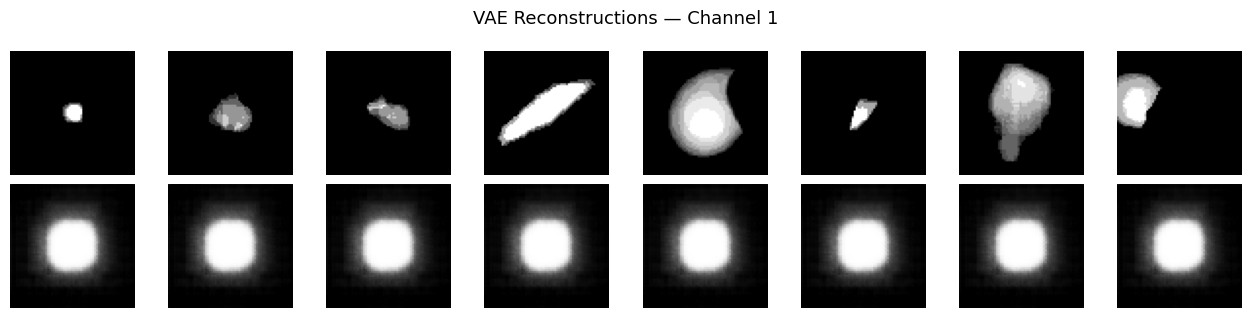

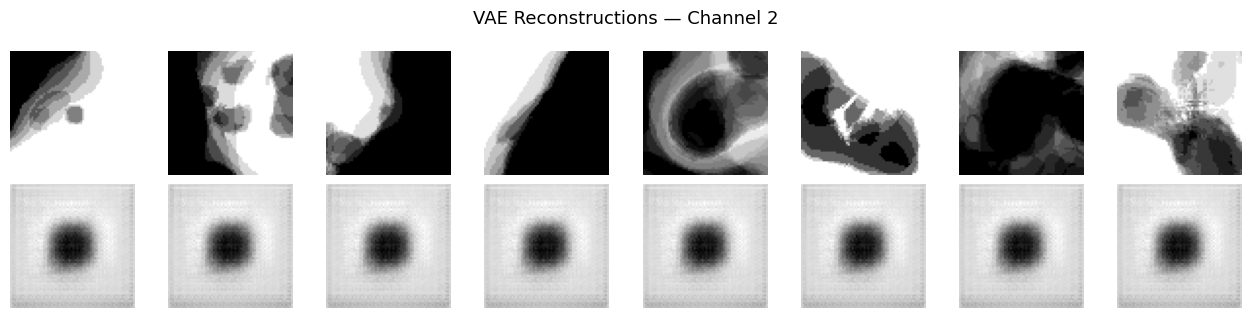

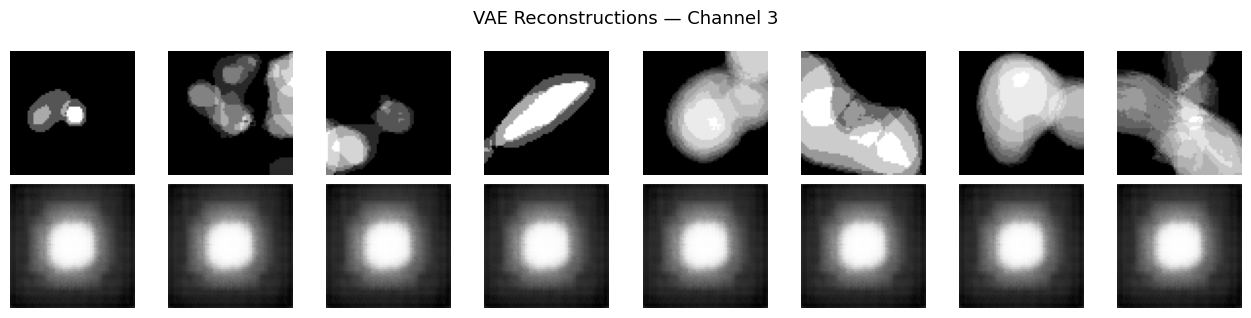

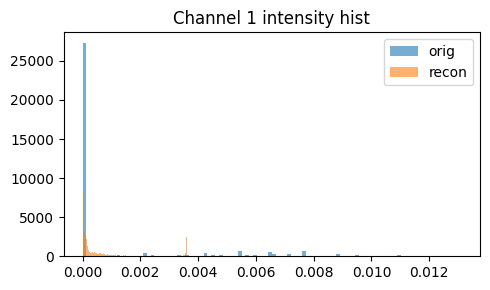

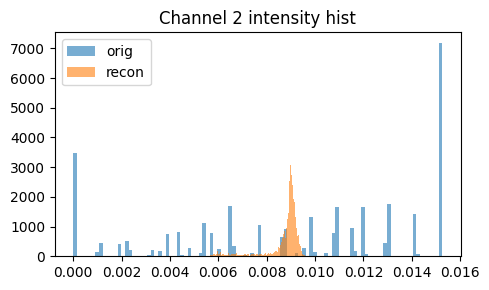

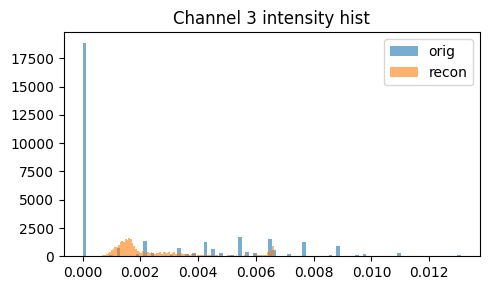

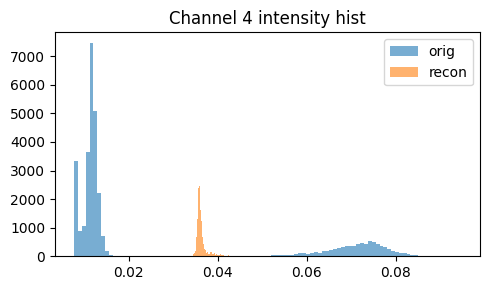

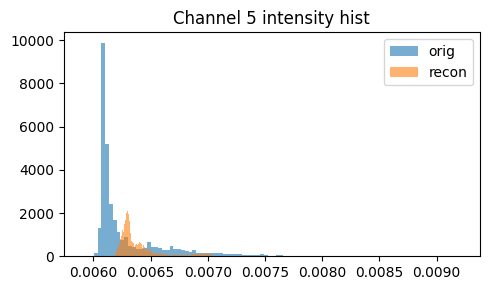

In [19]:
def denorm(t, mean_vals=None, std_vals=None):
    """
    t: torch tensor (B,C,...) in normalized space.
    If mean/std provided (per-channel), invert z-score; else map from [-1,1] -> [0,1].
    """
    if mean_vals is not None and std_vals is not None:
        mean = torch.tensor(mean_vals, dtype=t.dtype, device=t.device).view(1, -1, *([1] * (t.ndim-2)))
        std  = torch.tensor(std_vals,  dtype=t.dtype, device=t.device).view(1, -1, *([1] * (t.ndim-2)))
        x = t * (std + 1e-8) + mean
    else:
        x = (t * 0.5) + 0.5
    return x.clamp(0, 1)

def show_reconstructions(model, dataloader, device, num_images=8, channels_to_plot=None,
                         mean_vals=None, std_vals=None):
    model.eval()
    x, _ = next(iter(dataloader))
    x = x[:num_images].to(device)

    with torch.no_grad():
        # deterministic recons for fair visual compare
        x_recon, _, _ = model(x, return_z=False, latent_type="mu")

    # denorm to [0,1] for display
    x_vis      = denorm(x,       mean_vals, std_vals).detach().cpu()
    x_recon_vis= denorm(x_recon, mean_vals, std_vals).detach().cpu()

    C = x_vis.shape[1]
    if channels_to_plot is None:
        channels_to_plot = [0]

    # 2D case
    if x_vis.ndim == 4:
        for ch in channels_to_plot:
            if ch >= C:
                print(f"⚠️ Skipping channel {ch}: only {C} channels available."); 
                continue
            fig, axes = plt.subplots(2, num_images, figsize=(num_images * 1.6, 3.2))
            for i in range(num_images):
                axes[0, i].imshow(x_vis[i, ch], cmap='gray')
                axes[1, i].imshow(x_recon_vis[i, ch], cmap='gray')
                axes[0, i].axis("off"); axes[1, i].axis("off")
            axes[0, 0].set_ylabel(f"Original (Ch {ch})", fontsize=11)
            axes[1, 0].set_ylabel("Reconstruction", fontsize=11)
            fig.suptitle(f"VAE Reconstructions — Channel {ch+1}", fontsize=13)
            plt.tight_layout(); plt.show()

    # 3D case: show center slice
    elif x_vis.ndim == 5:
        D = x_vis.shape[2]
        mid = D // 2
        for ch in channels_to_plot:
            if ch >= C:
                print(f"⚠️ Skipping channel {ch}: only {C} channels available."); 
                continue
            fig, axes = plt.subplots(2, num_images, figsize=(num_images * 1.6, 3.2))
            for i in range(num_images):
                axes[0, i].imshow(x_vis[i, ch, mid], cmap='gray')
                axes[1, i].imshow(x_recon_vis[i, ch, mid], cmap='gray')
                axes[0, i].axis("off"); axes[1, i].axis("off")
            axes[0, 0].set_ylabel(f"Orig mid-slice (Ch {ch})", fontsize=11)
            axes[1, 0].set_ylabel("Recon mid-slice", fontsize=11)
            fig.suptitle(f"VAE 3D Recon — Channel {ch+1}", fontsize=13)
            plt.tight_layout(); plt.show()
    else:
        print(f"Unexpected tensor ndim={x_vis.ndim}")

# call it (don’t assume 5 chans; use min)
n_show = 8
chs = list(range(min(3, channels)))  # show up to first 3 channels by default
show_reconstructions(model, loader, device, num_images=n_show, channels_to_plot=chs,
                     mean_vals=mean_vals, std_vals=std_vals)

# Histograms: compare original vs recon distributions per channel (on CPU)
x_batch, _ = next(iter(loader))
x_batch = x_batch[:1024]  # limit for speed
with torch.no_grad():
    x_recon_batch, _, _ = model(x_batch.to(device), return_z=False, latent_type="mu")
x_vis  = denorm(x_batch,        mean_vals, std_vals).cpu()
x_hatv = denorm(x_recon_batch,  mean_vals, std_vals).cpu()

for ch in range(min(channels, 6)):  # cap to 6 plots
    plt.figure(figsize=(5,3))
    plt.hist(x_vis[:, ch].flatten().numpy(), bins=100, alpha=0.6, label="orig")
    plt.hist(x_hatv[:, ch].flatten().numpy(), bins=100, alpha=0.6, label="recon")
    plt.title(f"Channel {ch+1} intensity hist")
    plt.legend(); plt.tight_layout(); plt.show()


## Save Checkpoint

In [21]:
# ===== SIMPLE SAVE (right after training) =====
ckpt_path = "vae_checkpoint_simple.pth"

torch.save({
    "epoch": epoch + 1,                 # last finished epoch index + 1
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "norm_stats": {"mean": mean_vals, "std": std_vals},
    "config": {
        "channels": int(channels),
        "latent_dim": int(latent_dim),
        "is_3d": bool(is_3d),
    },
}, ckpt_path)

print(f"✅ Saved to {ckpt_path}")


✅ Saved to vae_checkpoint_simple.pth


## Load Checkpoint & Rebuild Dataset

In [25]:
# ===== LOAD (dynamic model, simple checkpoint) =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = "vae_checkpoint_simple.pth"   # <- or your path

print(f"📦 Loading checkpoint from: {ckpt_path}")
ckpt = torch.load(ckpt_path, map_location=device)

cfg = ckpt["config"]
mean_vals = ckpt["norm_stats"]["mean"]
std_vals  = ckpt["norm_stats"]["std"]

# dynamic model: no image_size arg
model = VAEUnified(
    in_channels=cfg["channels"],
    latent_dim=cfg["latent_dim"],
    is_3d=cfg["is_3d"]
).to(device)

# 🔧 warm-build so layers exist on the right device
print("🔧 Building model structure on device...", end="")
xb, _ = next(iter(loader))     
with torch.no_grad():
    _ = model(xb[:1].to(device), return_z=False, latent_type="mu")
print(" done.")

# now load weights
print("📥 Loading model weights...")
missing, unexpected = model.load_state_dict(ckpt["model_state_dict"], strict=False)
if missing or unexpected:
    print("⚠️ load_state_dict differences:", {"missing": missing, "unexpected": unexpected})
else:
    print("✅ Weights loaded cleanly.")
model.eval()

# ===== DATASET RELOAD WITH PROGRESS BAR =====
print("📁 Rebuilding dataset from disk...")

# build list of paths with tqdm tracking
paths = list(Path(data_path_3D if cfg["is_3d"] else data_path_2D).rglob("*.tif"))
print(f"   Found {len(paths)} .tif files.")

# wrap paths inside the dataset but with tqdm inside __getitem__()
# (cleaner: manually iterate to warm_reader)

# Here we pre-scan with tqdm just to show that files are readable
for p in tqdm(paths[:50], desc="   Checking first 50 files"):
    _ = imread(str(p))  # light check; does not load whole dataset

# Now create the dataset object
dataset = TifDataset(
    root_dir=(data_path_3D if cfg["is_3d"] else data_path_2D),
    image_size=image_size,
    is_3d=cfg["is_3d"],
    num_channels=cfg["channels"],
    mean_vals=mean_vals,
    std_vals=std_vals,
    normalize=True
)

# Dataloader
print("📦 Creating dataloader...")
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=False)

print("✨ Reload complete. Model + dataset ready to use.")

📦 Loading checkpoint from: vae_checkpoint_simple.pth
🔧 Building model structure on device... done.
📥 Loading model weights...
✅ Weights loaded cleanly.
📁 Rebuilding dataset from disk...
   Found 10656 .tif files.


   Checking first 50 files:   0%|          | 0/50 [00:00<?, ?it/s]

📦 Creating dataloader...
✨ Reload complete. Model + dataset ready to use.


## Latent Extraction

In [26]:
# ===== LATENT EXTRACTION =====
latent_type = "mu"   # 'mu' = deterministic, best for clustering/UMAP
z_list = []

print("🧬 Beginning latent extraction...")
model.eval()

with torch.no_grad():
    for x, _ in tqdm(dataloader, desc="🔄 Extracting embeddings", unit="batch"):
        x = x.to(device, non_blocking=True)

        # forward pass (mu gives cleaner embeddings)
        _, _, _, z = model(x, return_z=True, latent_type=latent_type)

        # move to CPU immediately to free GPU VRAM
        z_list.append(z.cpu())

# concatenate into a single numpy array
z = torch.cat(z_list, dim=0).numpy()
print("✨ Embeddings shape:", z.shape)

# optionally save the latents
np.save("vae_latents.npy", z)
print("📦 Saved embeddings → vae_latents.npy")


🧬 Beginning latent extraction...


🔄 Extracting embeddings:   0%|          | 0/1332 [00:00<?, ?batch/s]

KeyboardInterrupt: 

## Dimensionality Reduction + Clustering Benchmark

In [ ]:

def compare_dim_reduction_and_clustering(z, n_clusters=5,
                                         pca_args=None, tsne_args=None, umap_args=None,
                                         hdbscan_args=None, dbscan_args=None):
    if pca_args is None:
        pca_args = dict(n_components=2, random_state=42)
    if tsne_args is None:
        tsne_args = dict(n_components=2, perplexity=30, random_state=42, init="pca")
    if umap_args is None:
        umap_args = dict(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    if hdbscan_args is None:
        hdbscan_args = dict(min_cluster_size=10)
    if dbscan_args is None:
        dbscan_args = dict(eps=0.5, min_samples=5)

    dr_methods = {
        "PCA": PCA(**pca_args),
        "t-SNE": TSNE(**tsne_args),
        "UMAP": umap.UMAP(**umap_args)
    }
    clusterers = {
        "KMeans": lambda X: KMeans(n_clusters=n_clusters, random_state=42).fit_predict(X),
        "Agglomerative": lambda X: AgglomerativeClustering(n_clusters=n_clusters).fit_predict(X),
        "GMM": lambda X: GaussianMixture(n_components=n_clusters, random_state=42).fit(X).predict(X),
        "DBSCAN": lambda X: DBSCAN(**dbscan_args).fit_predict(X),
        "HDBSCAN": lambda X: hdbscan.HDBSCAN(**hdbscan_args).fit_predict(X)
    }

    results = {}
    for dr_name, dr_model in dr_methods.items():
        print(f"\n🔍 Reducing dimensionality with: {dr_name}")
        z_reduced = dr_model.fit_transform(z)
        results[dr_name] = {"embedding": z_reduced}

        fig, axes = plt.subplots(1, len(clusterers), figsize=(22, 4))
        fig.suptitle(f"{dr_name} + Clustering", fontsize=14)

        for i, (clust_name, clust_func) in enumerate(clusterers.items()):
            labels = clust_func(z_reduced)
            results[dr_name][clust_name] = labels

            valid = labels != -1
            if np.any(valid) and len(set(labels[valid])) > 1:
                score = silhouette_score(z_reduced[valid], labels[valid])
            else:
                score = -1

            axes[i].scatter(z_reduced[:, 0], z_reduced[:, 1], c=labels, s=6)
            axes[i].set_title(f"{clust_name} (sil={score:.2f})")
            axes[i].set_xticks([]); axes[i].set_yticks([])

            results[dr_name][f"{clust_name}_silhouette"] = float(score)

        plt.tight_layout(); plt.show()

        df = pd.DataFrame(z_reduced, columns=["x", "y"])
        for method in clusterers.keys():
            df[method] = results[dr_name][method]
        df.to_csv(f"clusters_{dr_name}.csv", index=False)
        print(f"💾 Saved: clusters_{dr_name}.csv")
    return results

results = compare_dim_reduction_and_clustering(z, n_clusters=5)


## Latent Interpolation

In [ ]:

@torch.no_grad()
def interpolate_between_images(model, dataset, device, idx_a=0, idx_b=1, steps=7,
                               latent_type="mu", channel_to_show=0, save_path=None):
    """Encode two dataset items → blend in z → decode → grid."""
    model.eval()
    xa, _ = dataset[idx_a]; xb, _ = dataset[idx_b]
    xa = xa.unsqueeze(0).to(device); xb = xb.unsqueeze(0).to(device)
    _, mu_a, logvar_a = model(xa, return_z=False, latent_type=latent_type)
    _, mu_b, logvar_b = model(xb, return_z=False, latent_type=latent_type)
    def z_from(mu, logvar):
        if latent_type == "mu":
            return mu
        std = torch.exp(0.5 * logvar)
        return mu + 0.0 * std  # deterministic
    za, zb = z_from(mu_a, logvar_a), z_from(mu_b, logvar_b)
    alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z_interp = (1 - alphas) * za + alphas * zb
    xhats = model.model.decoder(model.model.decoder_input(z_interp)).cpu().numpy()
    fig, axes = plt.subplots(1, steps, figsize=(steps*1.6, 1.8))
    for i in range(steps):
        axes[i].imshow(xhats[i, channel_to_show], cmap='gray')
        axes[i].axis('off'); axes[i].set_title(f"{alphas[i].item():.2f}", fontsize=8)
    plt.suptitle(f"Latent Interpolation (ch {channel_to_show})", fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"💾 Saved interpolation grid to: {save_path}")
    plt.show()

# Example call (uncomment to run):
# interpolate_between_images(model, dataset, device, idx_a=0, idx_b=5, steps=7, channel_to_show=0, save_path="interp.png")


## Optional: Quick Smoke Test

In [ ]:

# Run a tiny overfit step just to validate the training loop
x, _ = next(iter(loader))
x = x.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
with torch.no_grad():
    x_hat, mu, logvar = model(x, return_z=False)
print("Forward pass OK. Shapes:", x.shape, x_hat.shape)
